# Lake Chlorophyll Levels and Buffer Zone Land Use Association Through Remote Sensing Data 

I will be investigating how the land use (Crop Land, Developed, Tree Cover, etc..) in a 50 meter buffer around lakes in Minnesota relate to chlorophyll levels, specifically at the peak of algal growth in September in 2025.

## Package Installation and Import

In [1]:
# Install if needed:
#%pip install requests pandas geopandas shapely rasterio pyproj tqdm matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd



# landcover
from requests import Session
import sys
sys.path.append('..')
from api_key import key
from tqdm.notebook import tqdm
from shapely.geometry import shape, mapping
from shapely import wkt
from rasterio.io import MemoryFile
from rasterio.mask import mask

## Exploratory Data Analysis
Review the project_EDA.ipynb file for the preliminary data loading and processing. Processed data was saved to .csv files to be used in this analysis as follows:
* buffer_zones.csv - geometry and area for 50 meter buffer zone around each body of water
* landuse_50m_buffers.csv - landuse categorization for the 50 meter buffer zones based on the proportion of pixel classification
* landuse_waterquality.csv - merged chlorophyll, water geometry, and bufferzone land use data

In [2]:
buffer_df = pd.read_csv('Data/buffer_zone.csv')
buffer_df.head()

,lake_id,lake_name,acres,chl_sept_2025,mean_chl_summer_2025,geometry,buffer_50m_acres
0,01000100,pine,373.578352,6.64,5.07,POLYGON ((-93.07480733436563 46.18449207011752...,92.222570
1,01000200,split rock,23.564396,12.07,13.35,POLYGON ((-93.16783523397069 46.40647540162632...,18.673337
2,01000300,sandabacka,27.635120,3.85,4.06,POLYGON ((-93.13992759679856 46.55221087487485...,17.117370
3,01000400,dutch,43.687367,4.02,4.42,POLYGON ((-93.13932494060849 46.54836930147139...,28.700297
4,01000600,mud,15.339665,3.46,3.46,POLYGON ((-93.06697020843744 46.64014040993508...,14.415326


In [3]:
landuse_df = pd.read_csv('Data/landuse_50m_buffers.csv')
landuse_df.head()

,lake_id,lake_name,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,TreeCover_count,TreeCover_prop,Water_count,Water_prop,Wetland_count,Wetland_prop,Ice_Snow_count,Ice_Snow_prop,Barren_count,Barren_prop
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,1607,0.340322,935,0.198009,1415,0.299661,0,0.0,0,0.0
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,184,0.195745,266,0.282979,448,0.476596,0,0.0,0,0.0
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,76,0.088785,122,0.142523,658,0.768692,0,0.0,0,0.0
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,262,0.178840,239,0.163140,964,0.658020,0,0.0,0,0.0
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0,0.000000,145,0.197011,591,0.802989,0,0.0,0,0.0


In [4]:
use_qual_df = pd.read_csv('Data/landuse_waterquality.csv')
use_qual_df.head()

,lake_id,lake_name_x,lcmap_year,buffer_50m_acres,total_landcover_pixels,NoData_count,Developed_count,Developed_prop,Cropland_count,Cropland_prop,...,Ice_Snow_prop,Barren_count,Barren_prop,majority_landuse,max_prop,lake_name_y,acres,geometry,chl_sept_2025,mean_chl_summer_2025
0,01000100,pine,2020,92.222570,4722,0,375,0.079416,368,0.077933,...,0.0,0,0.0,Mixed,0.340322,pine,373.578352,MULTIPOLYGON (((494787.3102710478 5115730.4233...,6.64,5.07
1,01000200,split rock,2020,18.673337,940,0,0,0.000000,36,0.038298,...,0.0,0,0.0,Mixed,0.476596,split rock,23.564396,MULTIPOLYGON (((487141.9481031423 5138924.8474...,12.07,13.35
2,01000300,sandabacka,2020,17.117370,856,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.768692,sandabacka,27.635120,MULTIPOLYGON (((489317.3155683675 5155438.2496...,3.85,4.06
3,01000400,dutch,2020,28.700297,1465,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.658020,dutch,43.687367,MULTIPOLYGON (((489438.37885170523 5155072.245...,4.02,4.42
4,01000600,mud,2020,14.415326,736,0,0,0.000000,0,0.000000,...,0.0,0,0.0,Wetland,0.802989,mud,15.339665,MULTIPOLYGON (((494876.9452372008 5165227.5983...,3.46,3.46


### Example Lakes with Landuse Buffers and September Chlorophyll
I want to show what the lakes look like surrounded by their buffer zones look like by comparing two lakes that I know personally, Harriet in Minneapolis and Belle Taine in Nevis.

In [5]:
# target lakes
target_ids = ["27001600", "29014600"]  # Harriet, Belle Taine

# make lake_id formatting consistent
buffer_df["lake_id"] = buffer_df["lake_id"].astype(str).str.zfill(8)
use_qual_df["lake_id"] = use_qual_df["lake_id"].astype(str).str.zfill(8)

# rebuild geometries from CSV text
buffer_df["buffer_geom"] = buffer_df["geometry"].apply(wkt.loads)
use_qual_df["lake_geom"] = use_qual_df["geometry"].apply(wkt.loads)

# lake geometries from use_qual_df are projected UTM
lake_gdf = gpd.GeoDataFrame(
    use_qual_df.drop(columns=["geometry"]),
    geometry="lake_geom",
    crs="EPSG:26915"
).to_crs("EPSG:4326")

# buffer geometries from buffer_df are already lon/lat
buffer_gdf = gpd.GeoDataFrame(
    buffer_df.drop(columns=["geometry"]),
    geometry="buffer_geom",
    crs="EPSG:4326"
)

# keep only target lakes
lake_map = lake_gdf[lake_gdf["lake_id"].isin(target_ids)].copy()
buffer_map = buffer_gdf[buffer_gdf["lake_id"].isin(target_ids)].copy()

print(lake_map[["lake_id", "lake_name_y", "acres", "mean_chl_summer_2025", "majority_landuse", "max_prop"]])

       lake_id  lake_name_y        acres  mean_chl_summer_2025  \
3804  27001600      harriet   334.536311                  4.83   
4083  29014600  belle taine  1532.345070                  2.81   

     majority_landuse  max_prop  
3804        Developed  0.735937  
4083        TreeCover  0.566483  


In [6]:
# calculate the largest map window needed across both lakes
plot_windows = []

for lake_id in target_ids:
    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    minx = bounds["minx"].min()
    miny = bounds["miny"].min()
    maxx = bounds["maxx"].max()
    maxy = bounds["maxy"].max()

    width = maxx - minx
    height = maxy - miny

    plot_windows.append((width, height))

max_width = max(w for w, h in plot_windows)
max_height = max(h for w, h in plot_windows)

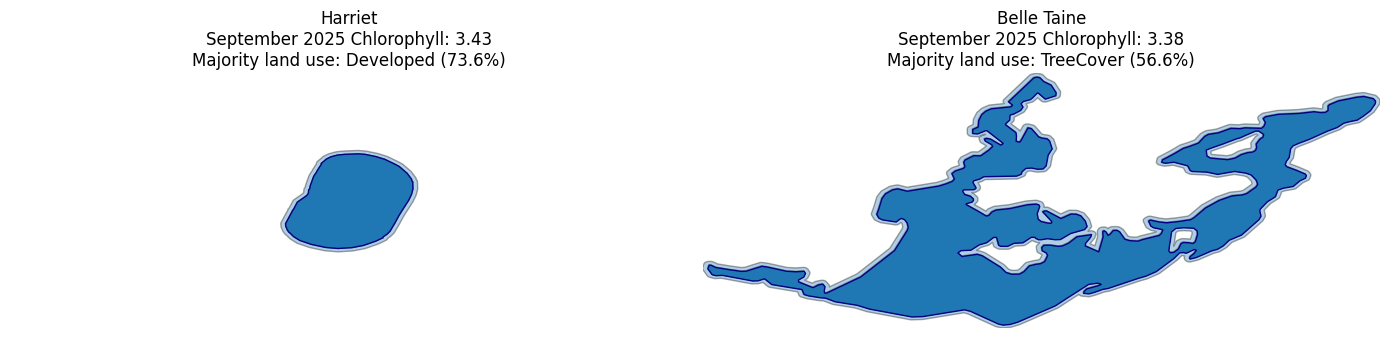

In [7]:
# AI help developing this visual

# calculate the largest map window needed across both lakes
plot_windows = []

for lake_id in target_ids:
    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    minx = bounds["minx"].min()
    miny = bounds["miny"].min()
    maxx = bounds["maxx"].max()
    maxy = bounds["maxy"].max()

    width = maxx - minx
    height = maxy - miny

    plot_windows.append((width, height))

max_width = max(w for w, h in plot_windows)
max_height = max(h for w, h in plot_windows)

# Plot the maps

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, lake_id in zip(axes, target_ids):

    lake = lake_map[lake_map["lake_id"] == lake_id]
    buffer = buffer_map[buffer_map["lake_id"] == lake_id]

    buffer.plot(ax=ax, alpha=0.35, edgecolor="black", linewidth=1)
    lake.plot(ax=ax, edgecolor="navy", linewidth=1)

    row = lake.iloc[0]

    # center each plot on its own lake/buffer
    bounds = pd.concat([
        lake.geometry.bounds,
        buffer.geometry.bounds
    ])

    center_x = (bounds["minx"].min() + bounds["maxx"].max()) / 2
    center_y = (bounds["miny"].min() + bounds["maxy"].max()) / 2

    # use the same extent for both maps
    ax.set_xlim(center_x - max_width / 2, center_x + max_width / 2)
    ax.set_ylim(center_y - max_height / 2, center_y + max_height / 2)

    ax.set_aspect("equal")

    ax.set_title(
        f"{row['lake_name_y'].title()}\n"
        f"September 2025 Chlorophyll: {row['chl_sept_2025']:.2f}\n"
        f"Majority land use: {row['majority_landuse']} ({row['max_prop']:.1%})"
    )

    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [8]:
lake_map[
    [
        "lake_id",
        "lake_name_y",
        "acres",
        "mean_chl_summer_2025",
        "chl_sept_2025",
        "majority_landuse",
        "max_prop",
        "Developed_prop",
        "Cropland_prop",
        "Grass_Shrub_prop",
        "TreeCover_prop",
        "Water_prop",
        "Wetland_prop"
    ]
]

,lake_id,lake_name_y,acres,mean_chl_summer_2025,chl_sept_2025,majority_landuse,max_prop,Developed_prop,Cropland_prop,Grass_Shrub_prop,TreeCover_prop,Water_prop,Wetland_prop
3804,27001600,harriet,334.536311,4.83,3.43,Developed,0.735937,0.735937,0.000000,0.000000,0.018273,0.245432,0.000358
4083,29014600,belle taine,1532.345070,2.81,3.38,TreeCover,0.566483,0.061645,0.017172,0.003907,0.566483,0.236451,0.108163


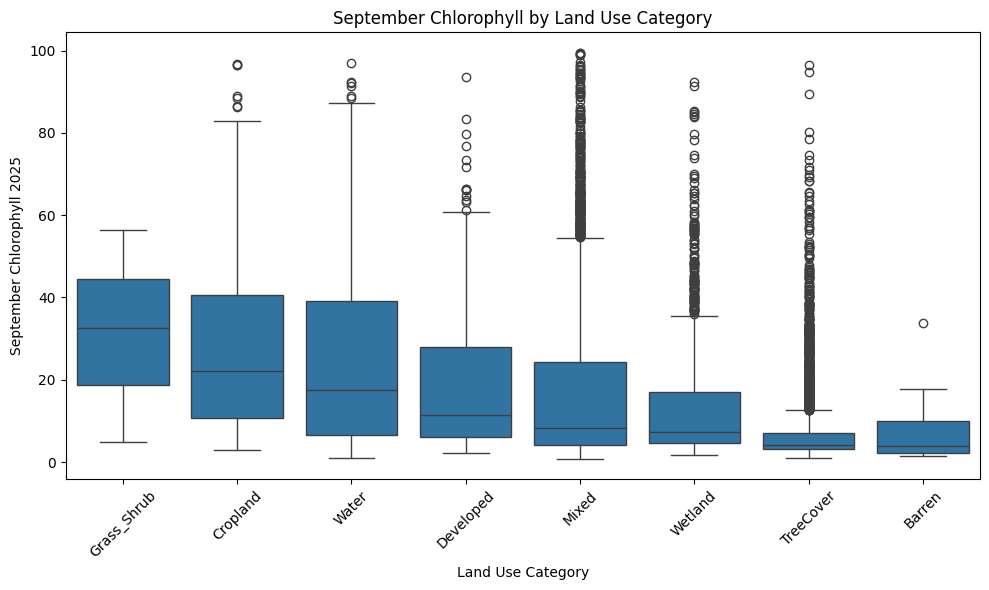

In [10]:
# box plot of September 2025 chlorophyll values for each land use category
category_order = (
    use_qual_df
    .groupby("majority_landuse")["chl_sept_2025"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=use_qual_df,
    x="majority_landuse",
    y="chl_sept_2025",
    order=category_order
)

plt.title("September Chlorophyll by Land Use Category")
plt.xlabel("Land Use Category")
plt.ylabel("September Chlorophyll 2025")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Permutation Test - F Statistic of Land Use Category x September Chlorophyll

Compare between-group variation in chlorophyll to within-group variation in chlorophyll. A large F indicates the mean chlorophyll are spread far apart relative to the noise withing each land use category and a small F indicates the land use categories look like they have the same chlorophyll distribution.

$$F = \frac{\text{between-group variability}}{\text{within-group variability}}$$

The land use labels will be shuffled and the f-statistic will be re-calculated for this permutation test. The repetition of this suffling will create the null distribution that the observed F-statistic can be compared to.

In [11]:
# creating a summary table with the body of water count, median september chl-a, mean september chl-a, stdev chl-a value for each land use category
summary_table = (
    use_qual_df
    .groupby("majority_landuse")["chl_sept_2025"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

summary_table

,majority_landuse,count,mean,median,std
0,Barren,18,7.611667,3.935,8.355256
1,Cropland,326,28.523712,22.010,21.717943
2,Developed,216,20.429954,11.445,19.840243
3,Grass_Shrub,3,31.310000,32.590,25.713905
4,Mixed,3939,17.621186,8.280,19.507237
5,TreeCover,3337,7.713917,4.140,9.972857
6,Water,652,25.161810,17.605,22.359135
7,Wetland,1415,13.687067,7.240,14.455810


/var/folders/sf/gq7bmv9j1bq7b7tn2rvctcw40000gn/T/ipykernel_92918/2675167169.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat,labels=category_order,patch_artist=True,medianprops=dict(color="black", linewidth=2))


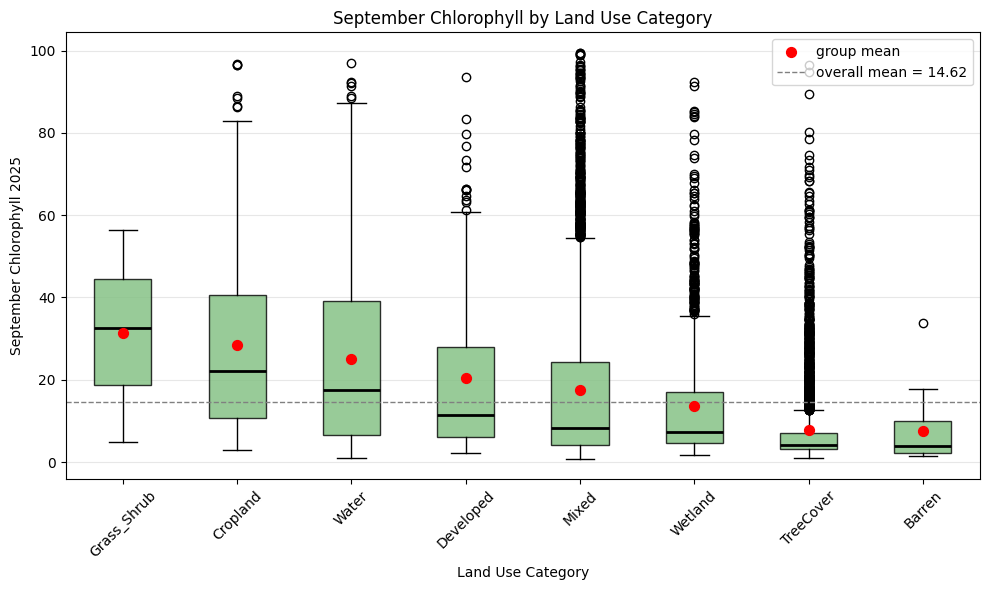

In [14]:
# Boxplots of the september chlorophyll by majority landuse category. The observed F-statistic will be the separation in means vs the shape of the box plot


# group + order by median (same logic you used)
category_order = use_qual_df.groupby("majority_landuse")["chl_sept_2025"].median().sort_values(ascending=False).index
groups = use_qual_df.groupby("majority_landuse")

# prepare data for boxplot
data_by_cat = [groups.get_group(cat)["chl_sept_2025"].dropna().values for cat in category_order]

# summary stats (for means)
group_summary = use_qual_df.groupby("majority_landuse")["chl_sept_2025"].agg(["mean", "median"])

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(data_by_cat,labels=category_order,patch_artist=True,medianprops=dict(color="black", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#7fbf7f")  
    patch.set_alpha(0.8)

# overlay group means
means = [group_summary.loc[cat, "mean"] for cat in category_order]

ax.scatter(range(1, len(category_order) + 1),means,color="red",s=50,zorder=5,label="group mean")

# overall mean line
grand_mean = use_qual_df["chl_sept_2025"].mean()

ax.axhline(grand_mean,color="gray",linestyle="--",linewidth=1,label=f"overall mean = {grand_mean:.2f}")

# labels + styling
ax.set_ylabel("September Chlorophyll 2025")
ax.set_xlabel("Land Use Category")
ax.set_title("September Chlorophyll by Land Use Category")

ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Computing Observed F-Statistic
Quotient of of between group sum of squares (SSB) and within group sum of squares (SSW)

In [15]:
def calc_f_stat(values, groups):
    """Compute one-way ANOVA F-statistic from raw arrays."""
    values = np.asarray(values)
    groups = np.asarray(groups)
    grand_mean = values.mean()
    n_total = len(values)
    levels = np.unique(groups)
    k = len(levels)

    ss_between = 0.0
    ss_within = 0.0
    for lvl in levels:
        x = values[groups == lvl]
        n_g = len(x)
        ss_between += n_g * (x.mean() - grand_mean) ** 2
        ss_within += ((x - x.mean()) ** 2).sum()

    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (n_total - k)
    return ms_between / ms_within, ss_between, ss_within, k, n_total


chla = use_qual_df["chl_sept_2025"].values
use = use_qual_df["majority_landuse"].values

f_obs, ssb, ssw, k, n_total = calc_f_stat(chla, use)
df_between = k - 1
df_within = n_total - k

print(f"Between-group SS: {ssb:.2f}  (df = {df_between})")
print(f"Within-group  SS: {ssw:.2f}  (df = {df_within})")
print(f"Mean square between: {ssb / df_between:.3f}")
print(f"Mean square within : {ssw / df_within:.3f}")
print(f"\nObserved F-statistic: {f_obs:.3f}")


Between-group SS: 340352.93  (df = 7)
Within-group  SS: 2691700.16  (df = 9898)
Mean square between: 48621.847
Mean square within : 271.944

Observed F-statistic: 178.794


### Permutation test on F-Statistic
Shuffle land use labels and recompute the F-statistic to generate data under null hypothesis. Compare the observed F to the distribution of permuted F values and calculate the p-value.

In [16]:
rng = np.random.default_rng(seed=631)
n_replicates = 1000
permuted_F = np.empty(n_replicates)

for i in range(n_replicates):
    shuffled_use = rng.permutation(use)
    permuted_F[i], _, _, _, _ = calc_f_stat(chla, shuffled_use)

p_value_F = (permuted_F >= f_obs).mean()

print(f"Observed F: {f_obs:.3f}")
print(f"Permutation p-value: {p_value_F:.4f}")

Observed F: 178.794
Permutation p-value: 0.0000


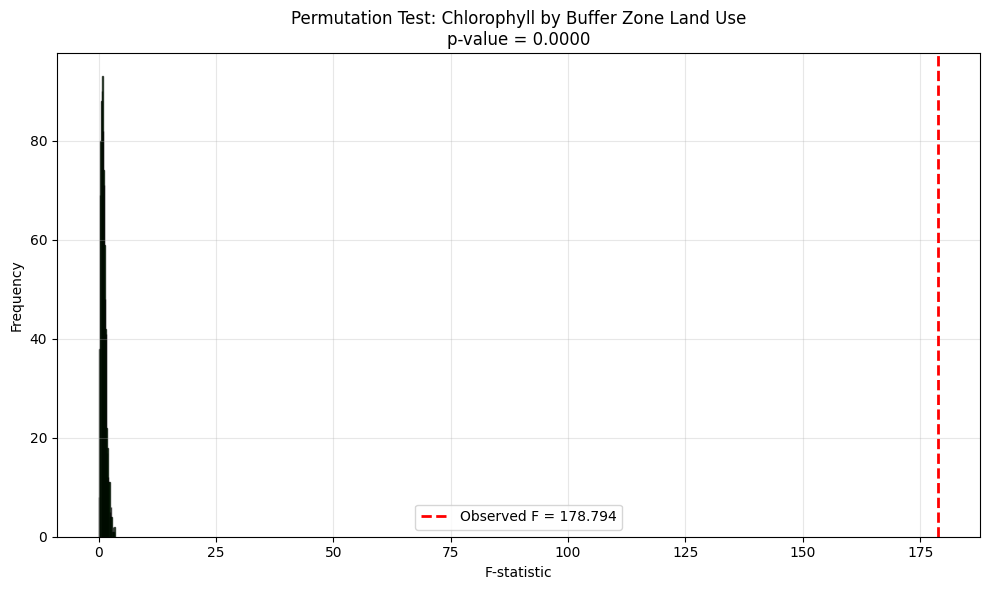

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(permuted_F, bins=30, color="green", edgecolor="black", alpha=0.7)
plt.axvline(f_obs, color="red", linestyle="--", linewidth=2,
            label=f"Observed F = {f_obs:.3f}")
plt.xlabel("F-statistic")
plt.ylabel("Frequency")
plt.title(f"Permutation Test: Chlorophyll by Buffer Zone Land Use\np-value = {p_value_F:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bootstrap 1 - Median Chlorophyll

## Bootstrap 2 - Mean Chlorophyll by Land Use Category
